# EDA - Exploratory Data Analysis

- **Measurement data**: 70 real-world trips (TripA warm weather, TripB cold weather)
- **Simulation data**: 24 simulated scenarios (3 temps × 4 scenarios × 2 bus types)

Sections: temporal profiles, distributions, correlations, SoC analysis, driving phases, sensor noise, simulation overview, real vs sim comparison, thermal analysis, scenario comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = r'c:\Users\rayen\Desktop\bms-engineering-assistant'
meas = pd.read_csv(f'{PROJECT_ROOT}/data/cleaned/measurement/measurement_clean.csv')
sim  = pd.read_csv(f'{PROJECT_ROOT}/data/cleaned/simulation/simulation_clean.csv')

print(f"Measurement: {meas.shape[0]:,} rows × {meas.shape[1]} cols, {meas['trip_id'].nunique()} trips")
print(f"Simulation:  {sim.shape[0]:,} rows × {sim.shape[1]} cols, {sim['sim_id'].nunique()} simulations")

print("\nMeasurement - first 5 rows:")
display(meas.head())

print("\nSimulation - first 5 rows:")
display(sim.head())

Measurement: 1,064,082 rows × 24 cols, 70 trips
Simulation:  917,280 rows × 25 cols, 24 simulations

Measurement - first 5 rows:


,trip_id,time_s,velocity_kmh,elevation_m,throttle_pct,motor_torque_nm,longitudinal_acceleration_ms2,regen_braking_signal,battery_voltage_v,battery_current_a,...,aircon_power_kw,heater_voltage_v,heater_current_a,battery_temperature_c,max_battery_temperature_c,ambient_temperature_c,coolant_temp_heatercore_c,coolant_temp_inlet_c,heat_exchanger_temperature_c,cabin_temperature_c
0,TripA01,0.0,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.20,...,0.4,0.0,0.0,23.0,23.0,32.0,0.0,0.0,0.0,0.0
1,TripA01,0.1,0.0,574.0,0.0,0.0,0.00,0.0,391.4,-2.21,...,0.4,0.0,0.0,23.0,23.0,32.0,0.0,0.0,0.0,0.0
2,TripA01,0.2,0.0,574.0,0.0,0.0,-0.01,0.0,391.4,-2.26,...,0.4,0.0,0.0,23.0,23.0,32.0,0.0,0.0,0.0,0.0
3,TripA01,0.3,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,...,0.4,0.0,0.0,23.0,23.0,32.0,0.0,0.0,0.0,0.0
4,TripA01,0.4,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,...,0.4,0.0,0.0,23.0,23.0,32.0,0.0,0.0,0.0,0.0



Simulation - first 5 rows:


,sim_id,time_s,ambient_temperature_c,longitudinal_acceleration_ms2,speed_ms,traction_force_n,drive_torque_nm,em_power_kw,pack_voltage_v,battery_current_a,...,consumption_energy_kwh,cabin_temperature_c,heating_power_kw,heating_power_incl_peak_kw,heatexchanger_inlet_coolant_temp_c,heatexchanger_outlet_air_temp_c,auxiliaries_total_w,temperature,scenario,bus_type
0,0_Charging_CAN,0.0,0,0.0,0.0,0.0,0.0,-0.113686,405.048906,0.715774,...,0.000000,0.000000,0.0,0.0,0.0,4.000000e+00,403.61,0,Charging,CAN
1,0_Charging_CAN,0.1,0,0.0,0.0,0.0,0.0,-0.113686,400.652412,18.195132,...,0.000182,0.000003,7.0,7.0,0.0,0.000000e+00,7403.61,0,Charging,CAN
2,0_Charging_CAN,0.2,0,0.0,0.0,0.0,0.0,-0.113686,399.839821,18.232110,...,0.000385,0.000006,7.0,7.0,0.0,0.000000e+00,7403.61,0,Charging,CAN
3,0_Charging_CAN,0.3,0,0.0,0.0,0.0,0.0,-0.113686,399.528019,18.246339,...,0.000588,0.000009,7.0,7.0,0.0,3.155440e-28,7403.61,0,Charging,CAN
4,0_Charging_CAN,0.4,0,0.0,0.0,0.0,0.0,-0.113686,399.401029,18.252140,...,0.000790,0.000011,7.0,7.0,0.0,5.684340e-14,7403.61,0,Charging,CAN


## 1. Temporal Profiles

Speed, current, SoC, and temperatures vs time for representative trips (warm and cold weather).

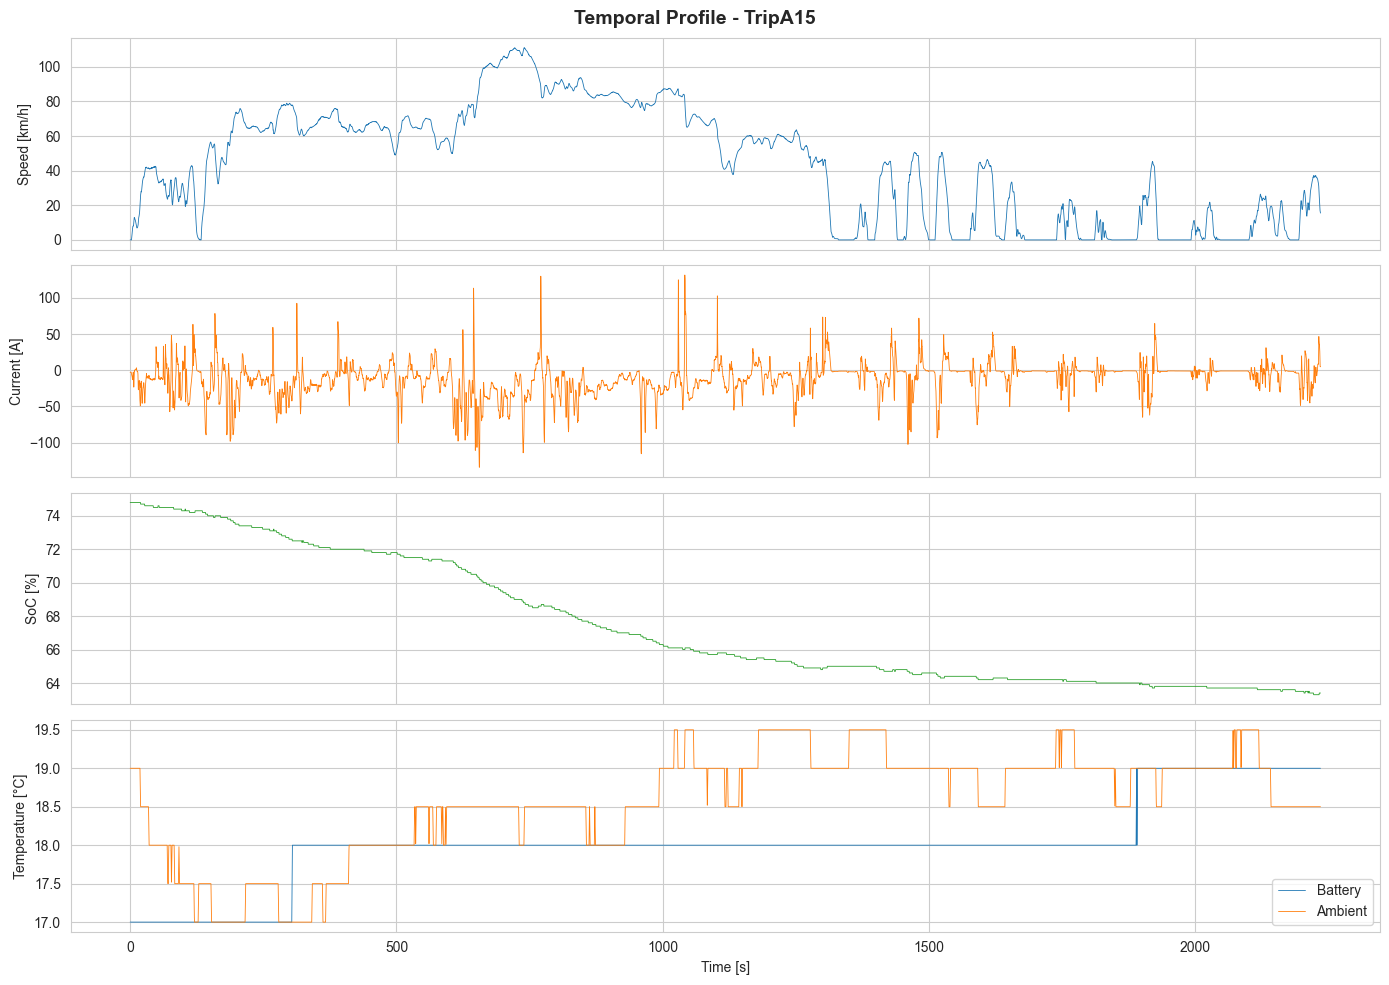

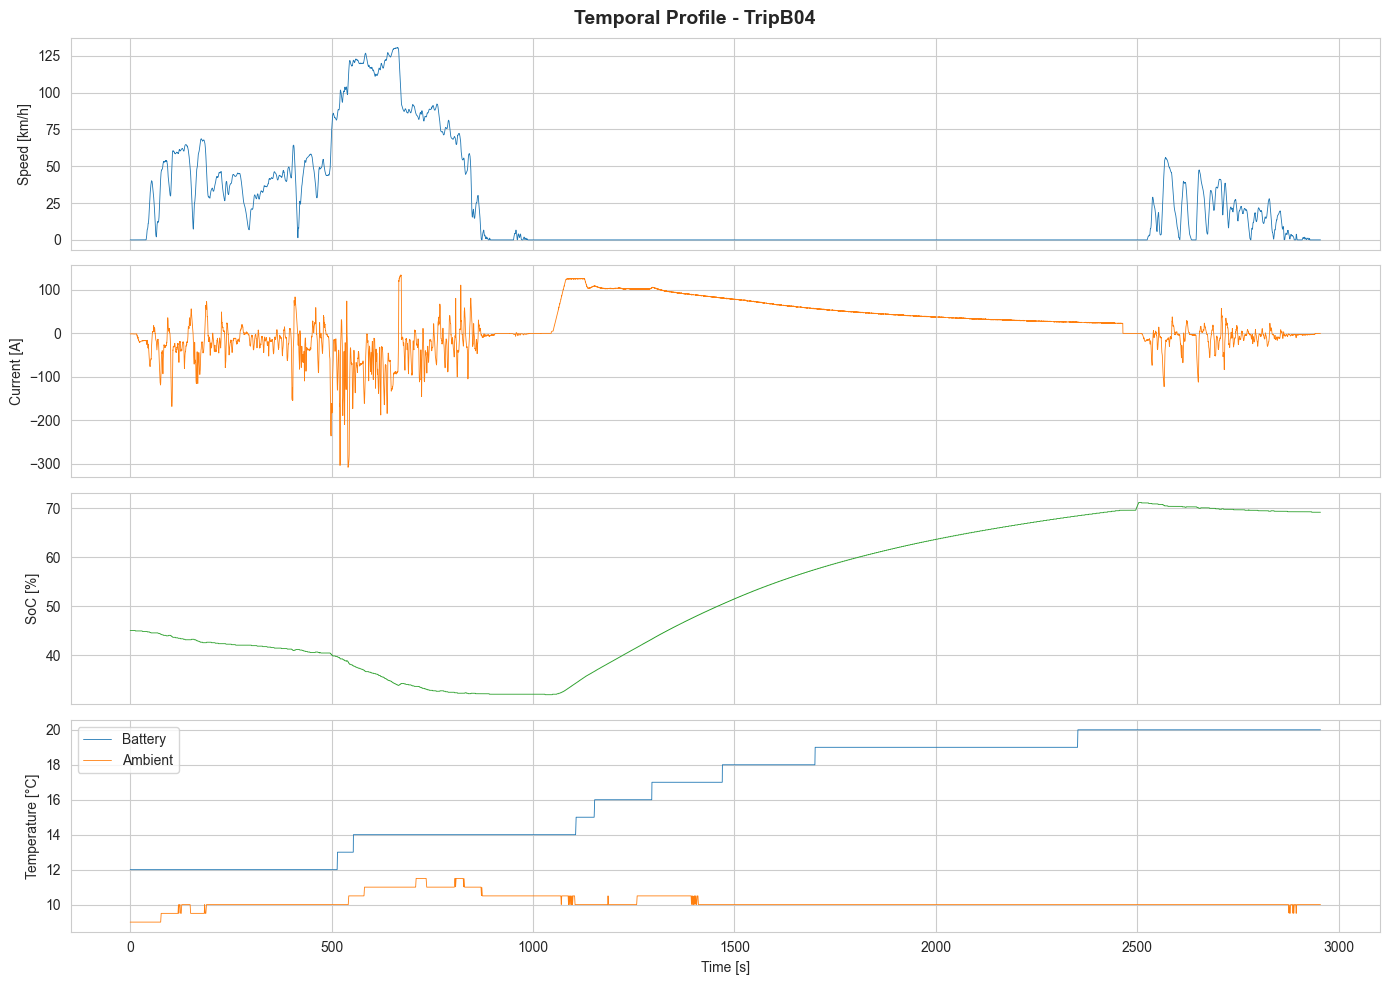

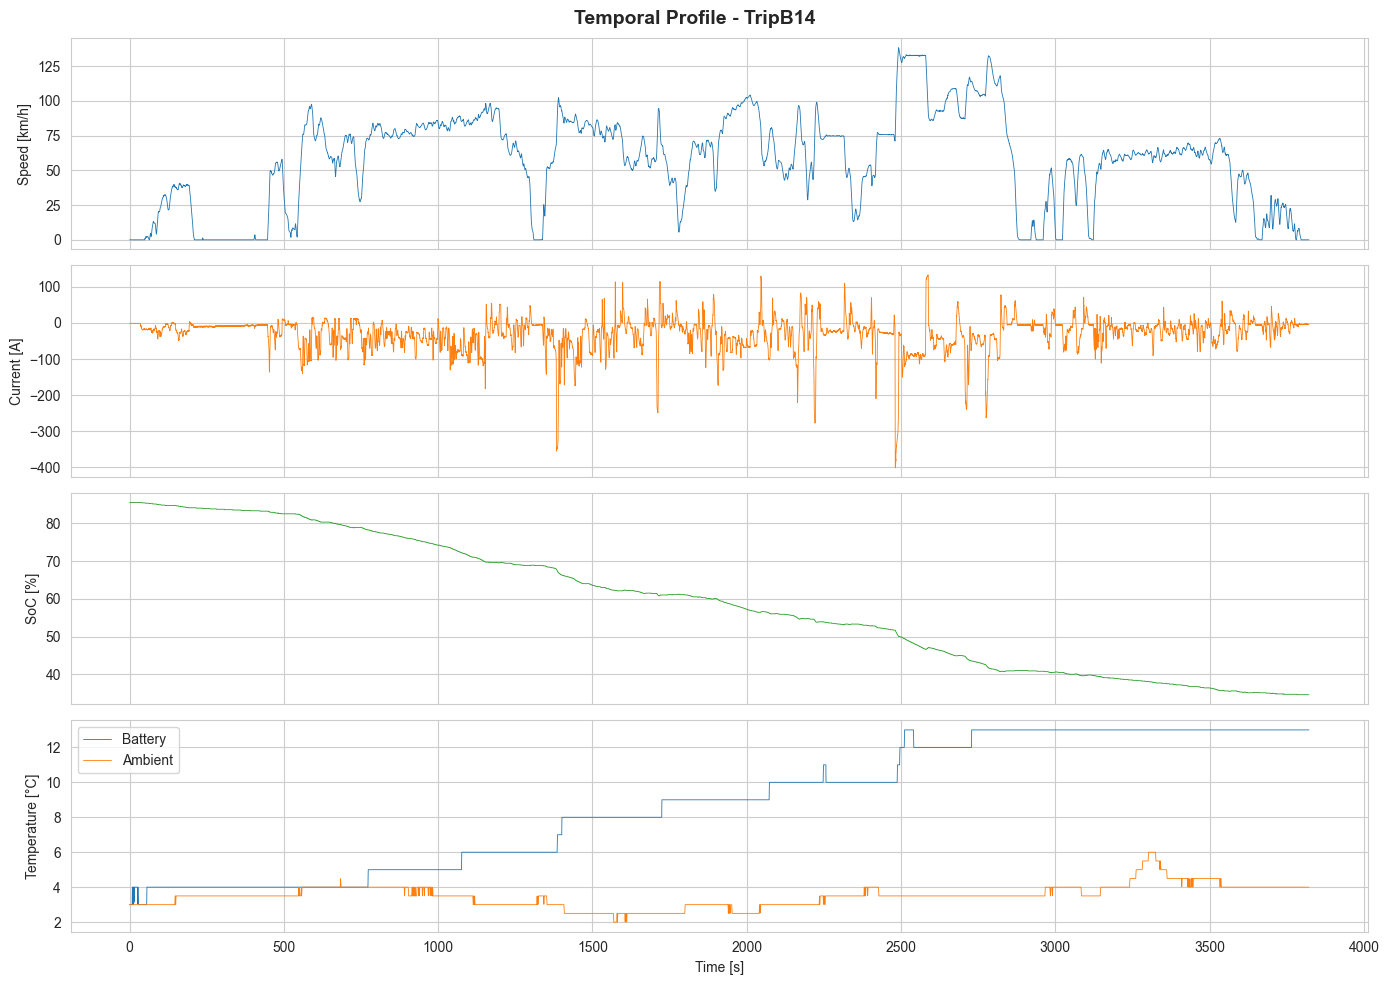

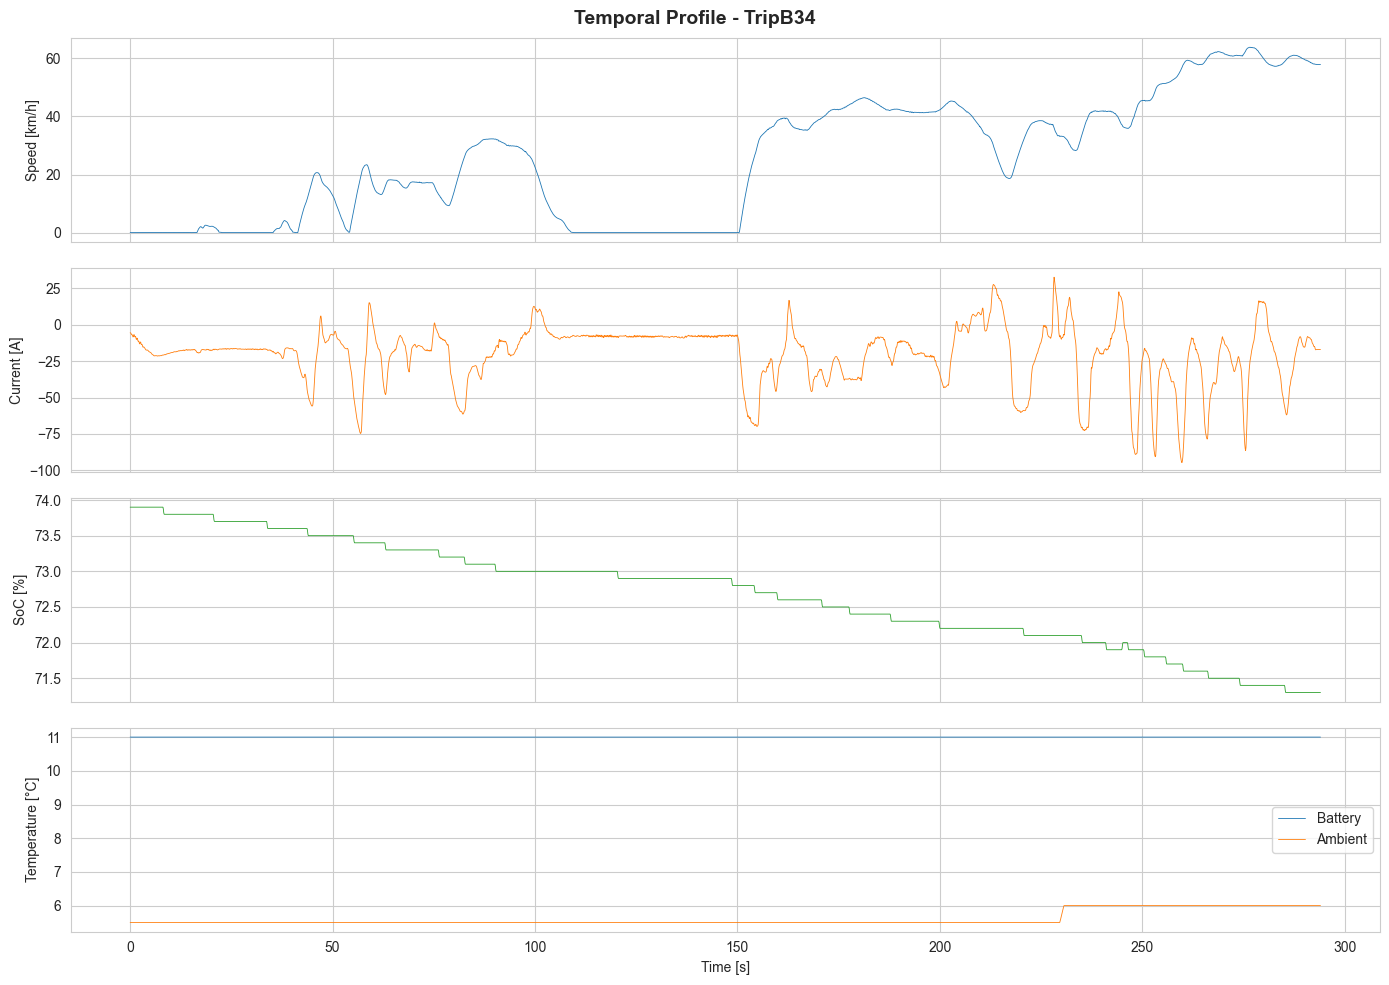

In [2]:
def plot_trip_profile(df, trip_id):
    """Plot speed, current, SoC, temperatures for one trip."""
    t = df[df['trip_id'] == trip_id]
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Temporal Profile - {trip_id}', fontsize=14, fontweight='bold')

    axes[0].plot(t['time_s'], t['velocity_kmh'], lw=0.6)
    axes[0].set_ylabel('Speed [km/h]')

    axes[1].plot(t['time_s'], t['battery_current_a'], lw=0.6, color='tab:orange')
    axes[1].set_ylabel('Current [A]')

    axes[2].plot(t['time_s'], t['soc_pct'], lw=0.6, color='tab:green')
    axes[2].set_ylabel('SoC [%]')

    axes[3].plot(t['time_s'], t['battery_temperature_c'], lw=0.6, label='Battery')
    axes[3].plot(t['time_s'], t['ambient_temperature_c'], lw=0.6, label='Ambient')
    axes[3].set_ylabel('Temperature [°C]')
    axes[3].set_xlabel('Time [s]')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

# warm and cold weather examples
for tid in ['TripA15', 'TripB04', 'TripB14', 'TripB34']:
    plot_trip_profile(meas, tid)

## 2. Statistical Distributions

Key signal distributions across all measurement trips, split by TripA (warm) vs TripB (cold).

,velocity_kmh,battery_current_a,battery_voltage_v,soc_pct,battery_temperature_c,ambient_temperature_c
count,1064082.00,1064082.00,1064082.00,1064082.00,1064082.00,1064082.00
mean,44.85,-19.44,376.21,65.10,15.51,13.23
std,35.53,42.26,11.80,15.12,7.52,9.73
min,0.00,-404.38,301.80,15.40,-1.00,-3.50
25%,14.50,-32.06,369.02,56.40,9.00,5.00
50%,40.84,-11.89,379.29,68.20,15.00,9.50
75%,68.29,-2.10,385.10,76.50,21.00,22.00
max,152.26,144.49,394.76,88.50,32.00,33.50


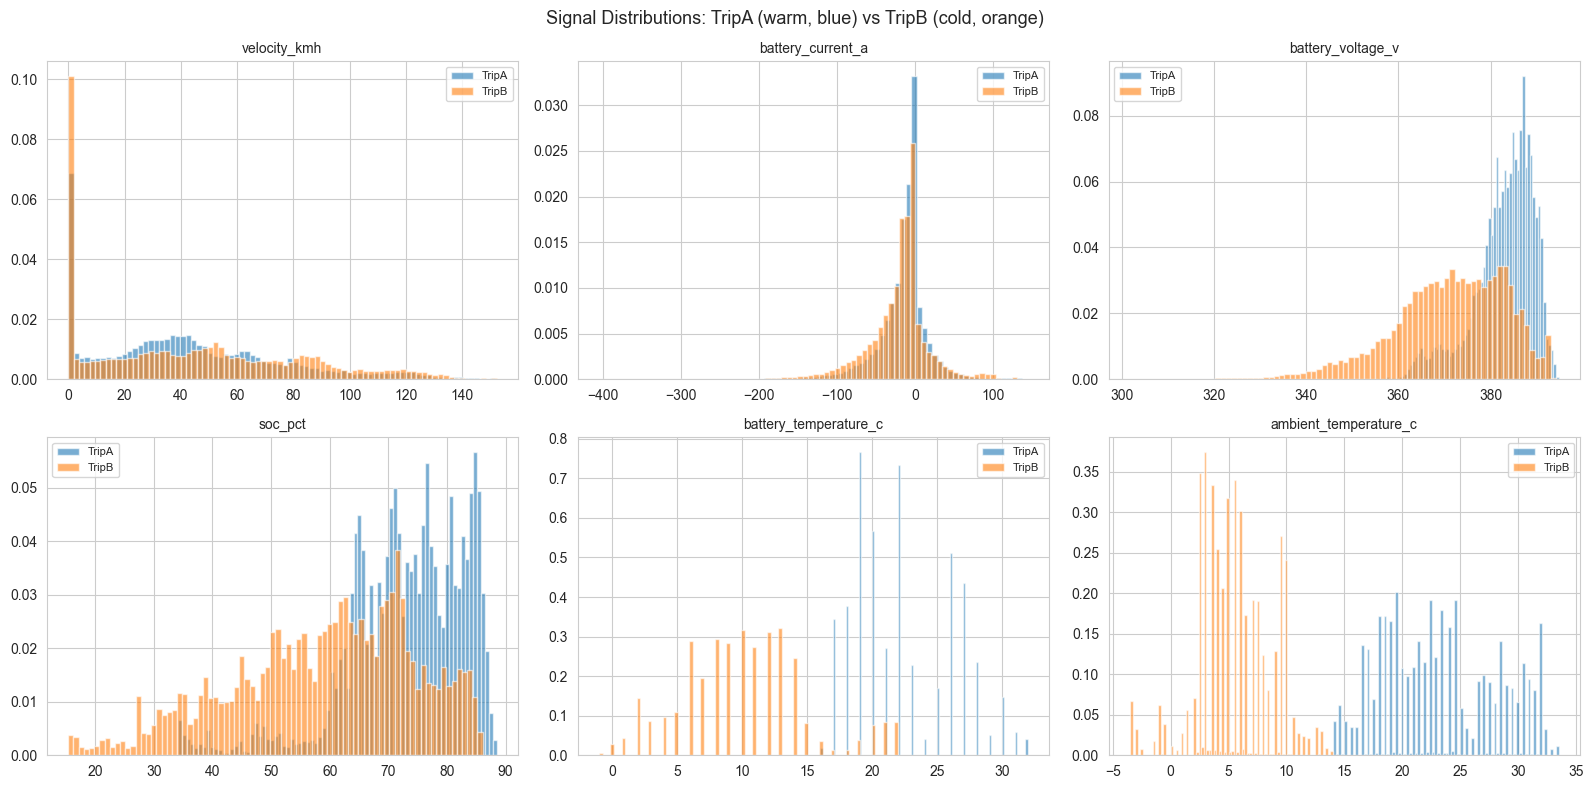

In [3]:
# descriptive statistics
key_cols = ['velocity_kmh', 'battery_current_a', 'battery_voltage_v', 'soc_pct',
            'battery_temperature_c', 'ambient_temperature_c']
display(meas[key_cols].describe().round(2))

# distribution plots: TripA vs TripB
meas_A = meas[meas['trip_id'].str.startswith('TripA')]
meas_B = meas[meas['trip_id'].str.startswith('TripB')]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Signal Distributions: TripA (warm, blue) vs TripB (cold, orange)', fontsize=13)

for ax, col in zip(axes.flat, key_cols):
    ax.hist(meas_A[col].dropna(), bins=80, alpha=0.6, density=True, label='TripA', color='tab:blue')
    ax.hist(meas_B[col].dropna(), bins=80, alpha=0.6, density=True, label='TripB', color='tab:orange')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

Pearson correlation matrix for key BMS signals (measurement data).

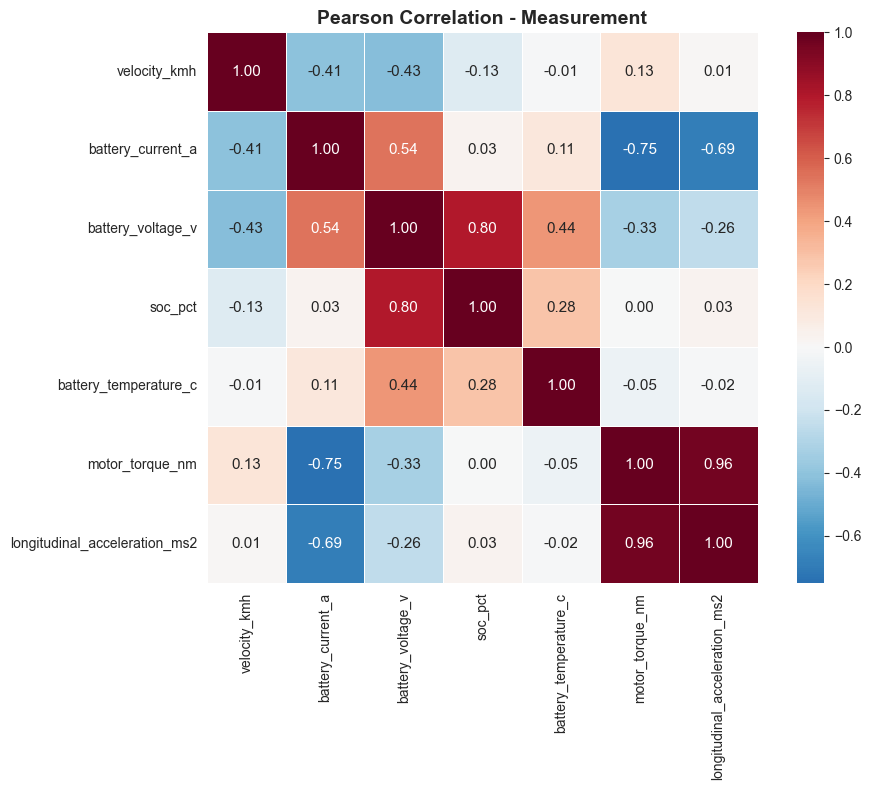

In [4]:
corr_cols = ['velocity_kmh', 'battery_current_a', 'battery_voltage_v',
             'soc_pct', 'battery_temperature_c', 'motor_torque_nm',
             'longitudinal_acceleration_ms2']
corr = meas[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Pearson Correlation - Measurement', fontweight='bold', fontsize=14)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## 4. SoC Range Analysis

SoC range per trip - helps identify charging, deep discharge, and typical usage patterns.

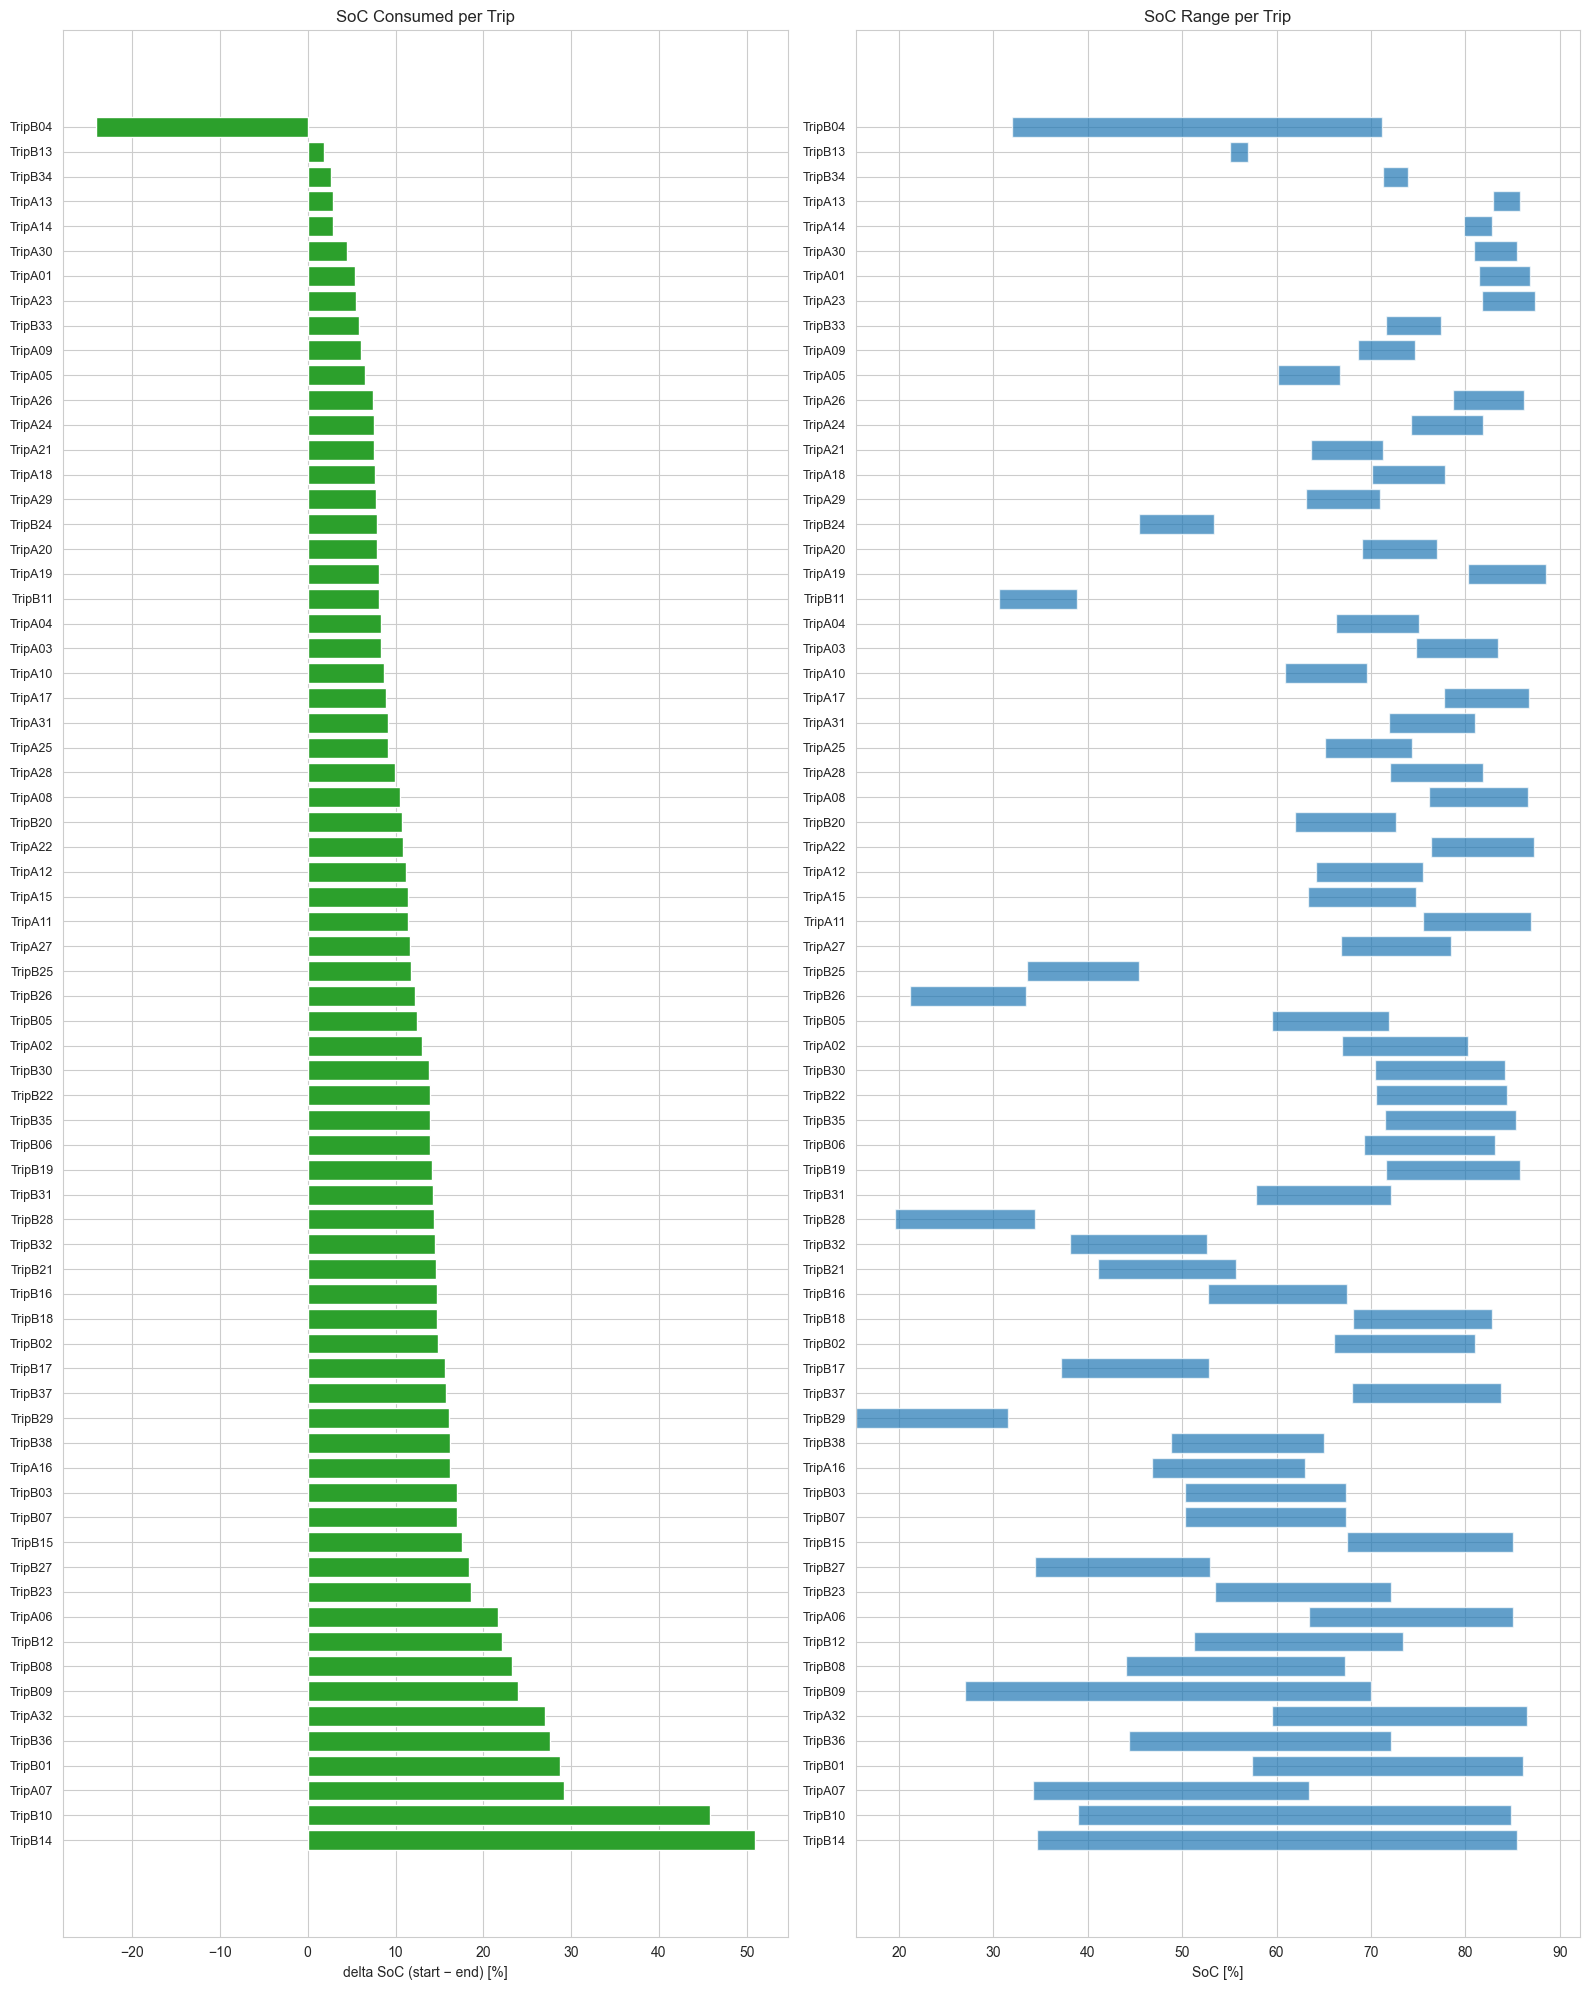

In [5]:
soc_stats = meas.groupby('trip_id')['soc_pct'].agg(
    soc_start='first', soc_end='last', soc_min='min', soc_max='max'
)
soc_stats['delta_soc'] = soc_stats['soc_start'] - soc_stats['soc_end']
soc_stats = soc_stats.sort_values('delta_soc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 20))

# delta SoC per trip
axes[0].barh(soc_stats.index, soc_stats['delta_soc'], color='tab:green')
axes[0].set_xlabel('delta SoC (start − end) [%]')
axes[0].set_title('SoC Consumed per Trip')
axes[0].tick_params(axis='y', labelsize=9)

# SoC min/max range
axes[1].barh(soc_stats.index, soc_stats['soc_max'] - soc_stats['soc_min'],
             left=soc_stats['soc_min'], color='tab:blue', alpha=0.7)
axes[1].set_xlabel('SoC [%]')
axes[1].set_title('SoC Range per Trip')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

## 5. Driving Phase Identification

Classify each timestep: acceleration, regenerative braking, cruising, rest, heating.

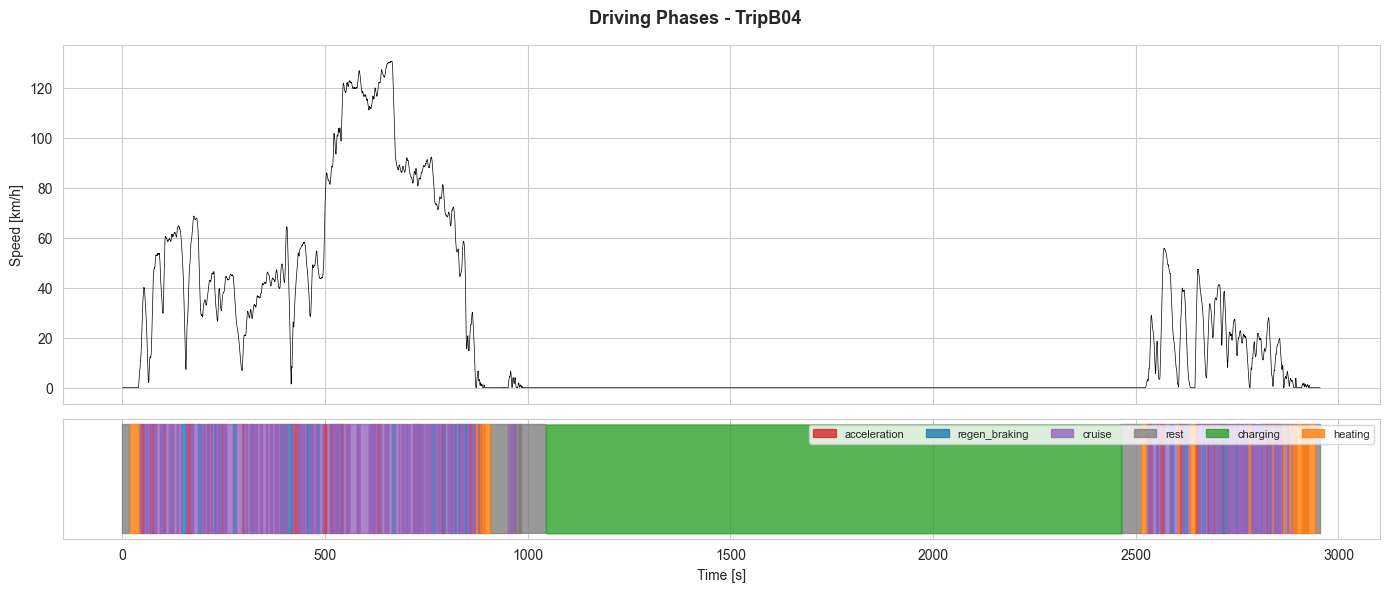

Phase durations [s]:
phase
charging         1419.1
cruise            742.8
acceleration      294.4
rest              197.0
regen_braking     181.5
heating           120.2


In [6]:
def classify_phase(df):
    """Assign a driving phase to each row."""
    speed = df['velocity_kmh']
    current = df['battery_current_a']
    soc_diff = df['soc_pct'].diff()
    accel = df.get('longitudinal_acceleration_ms2', speed.diff() / 0.36)

    phase = pd.Series('cruise', index=df.index)
    phase[speed < 1] = 'rest'
    phase[(speed < 1) & (current > 0.5) & (soc_diff >= 0)] = 'charging'
    phase[(speed >= 1) & (accel > 0.3)] = 'acceleration'
    phase[(speed >= 1) & (current > 5)] = 'regen_braking'
    if 'heating_power_can_kw' in df.columns:
        phase[(df['heating_power_can_kw'] > 0.1) & (speed < 1)] = 'heating'
    return phase

# apply to a representative cold-weather trip
trip = meas[meas['trip_id'] == 'TripB04'].copy()
trip['phase'] = classify_phase(trip)

phase_colors = {
    'acceleration': 'tab:red', 'regen_braking': 'tab:blue',
    'cruise': 'tab:purple', 'rest': 'gray',
    'charging': 'tab:green', 'heating': 'tab:orange',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Driving Phases - TripB04', fontsize=13, fontweight='bold')

axes[0].plot(trip['time_s'], trip['velocity_kmh'], lw=0.5, color='black')
axes[0].set_ylabel('Speed [km/h]')

for phase_name, color in phase_colors.items():
    mask = trip['phase'] == phase_name
    if mask.any():
        axes[1].fill_between(trip['time_s'], 0, 1, where=mask,
                             color=color, alpha=0.8, label=phase_name)
axes[1].set_yticks([])
axes[1].set_xlabel('Time [s]')
axes[1].legend(loc='upper right', ncol=6, fontsize=8)

plt.tight_layout()
plt.show()

# phase duration breakdown
dt = trip['time_s'].diff().median()
phase_dur = trip.groupby('phase').size() * dt
print('Phase durations [s]:')
print(phase_dur.sort_values(ascending=False).round(1).to_string())

## 6. Sensor Noise Analysis

Detect abnormal jumps in key signals. A spike is a sudden value change that is physically impossible.

Top 5 trips by max |delta SoC| per timestep:
trip_id
TripA06    0.30
TripA05    0.06
TripB31    0.06
TripA32    0.06
TripA28    0.05

Top 5 trips by max |delta Voltage| per timestep:
trip_id
TripB02    17.16
TripB14    10.80
TripB36     9.25
TripB01     9.15
TripB10     9.10


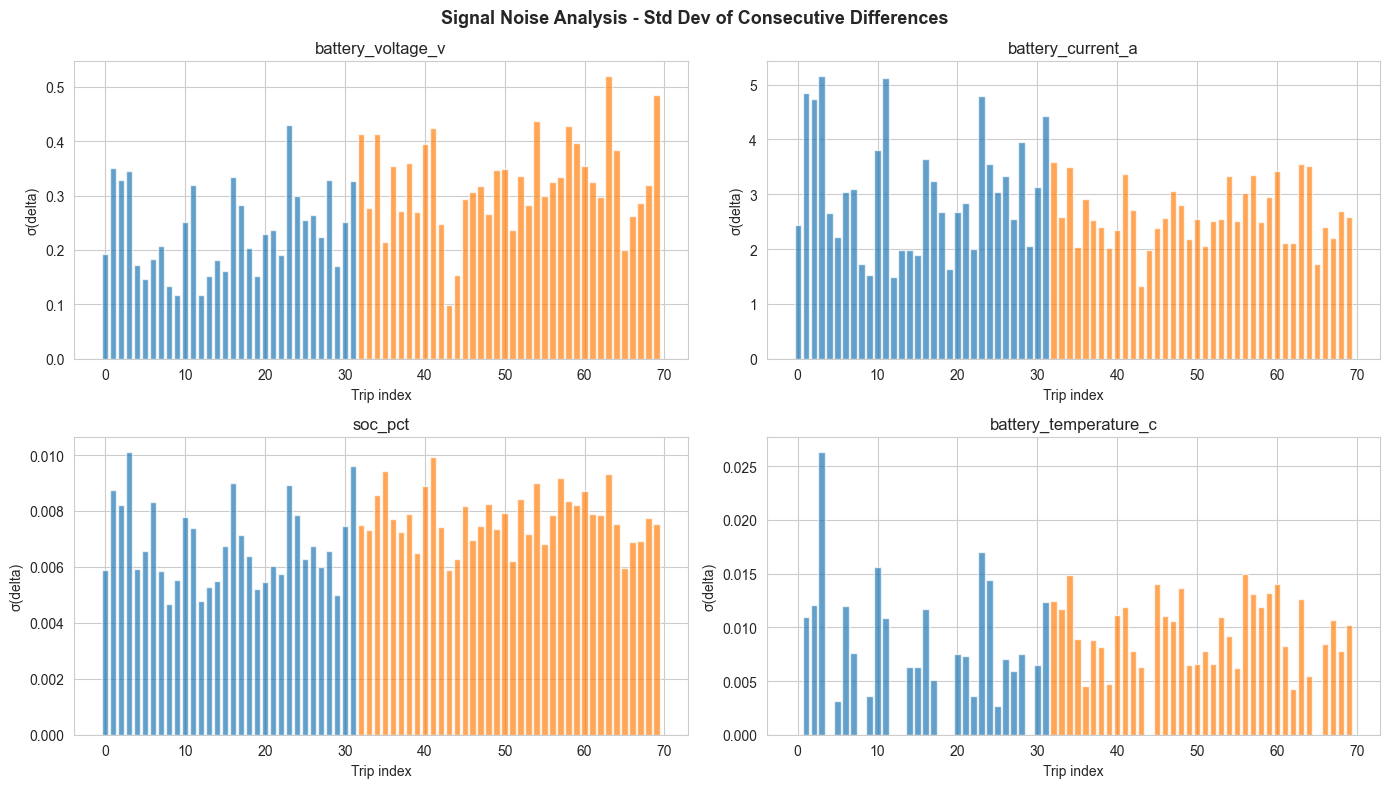

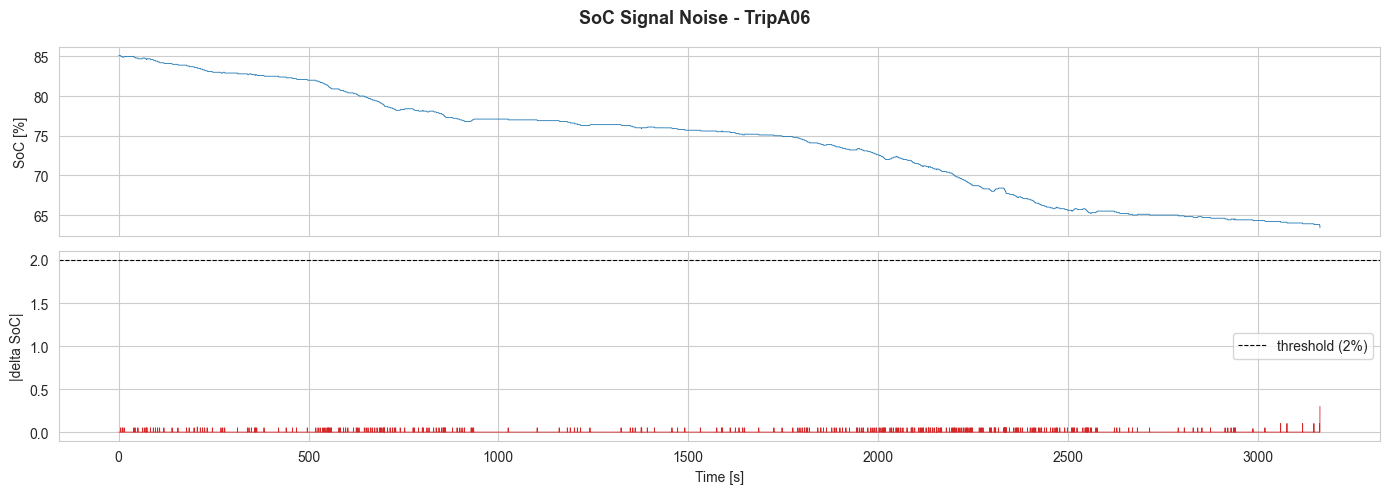

In [7]:
# compute per-trip signal noise: standard deviation of timestep-to-timestep differences
noise_cols = ['battery_voltage_v', 'battery_current_a', 'soc_pct', 'battery_temperature_c']

noise_stats = []
for tid, grp in meas.groupby('trip_id'):
    row = {'trip_id': tid}
    for col in noise_cols:
        diff = grp[col].diff().dropna()
        row[f'{col}_diff_std'] = diff.std()
        row[f'{col}_max_jump'] = diff.abs().max()
    noise_stats.append(row)
noise_df = pd.DataFrame(noise_stats).set_index('trip_id')

# show trips with largest max jumps
print("Top 5 trips by max |delta SoC| per timestep:")
print(noise_df['soc_pct_max_jump'].sort_values(ascending=False).head().round(2).to_string())
print("\nTop 5 trips by max |delta Voltage| per timestep:")
print(noise_df['battery_voltage_v_max_jump'].sort_values(ascending=False).head().round(2).to_string())

# plot noise levels per trip
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Signal Noise Analysis - Std Dev of Consecutive Differences', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, noise_cols):
    std_col = f'{col}_diff_std'
    colors = ['tab:blue' if t.startswith('TripA') else 'tab:orange' for t in noise_df.index]
    ax.bar(range(len(noise_df)), noise_df[std_col], color=colors, alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Trip index')
    ax.set_ylabel('σ(delta)')

plt.tight_layout()
plt.show()

# noisy trip: show raw signal with highlighted jumps
noisy_trip_id = noise_df['soc_pct_max_jump'].idxmax()
noisy = meas[meas['trip_id'] == noisy_trip_id].copy()
noisy['soc_diff'] = noisy['soc_pct'].diff().abs()

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle(f'SoC Signal Noise - {noisy_trip_id}', fontsize=13, fontweight='bold')

axes[0].plot(noisy['time_s'], noisy['soc_pct'], lw=0.6)
axes[0].set_ylabel('SoC [%]')

axes[1].plot(noisy['time_s'], noisy['soc_diff'], lw=0.6, color='tab:red')
axes[1].axhline(y=2.0, color='black', ls='--', lw=0.8, label='threshold (2%)')
axes[1].set_ylabel('|delta SoC|')
axes[1].set_xlabel('Time [s]')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Simulation Data Overview

Compare simulation profiles at different temperatures for the Standard scenario (CAN bus).

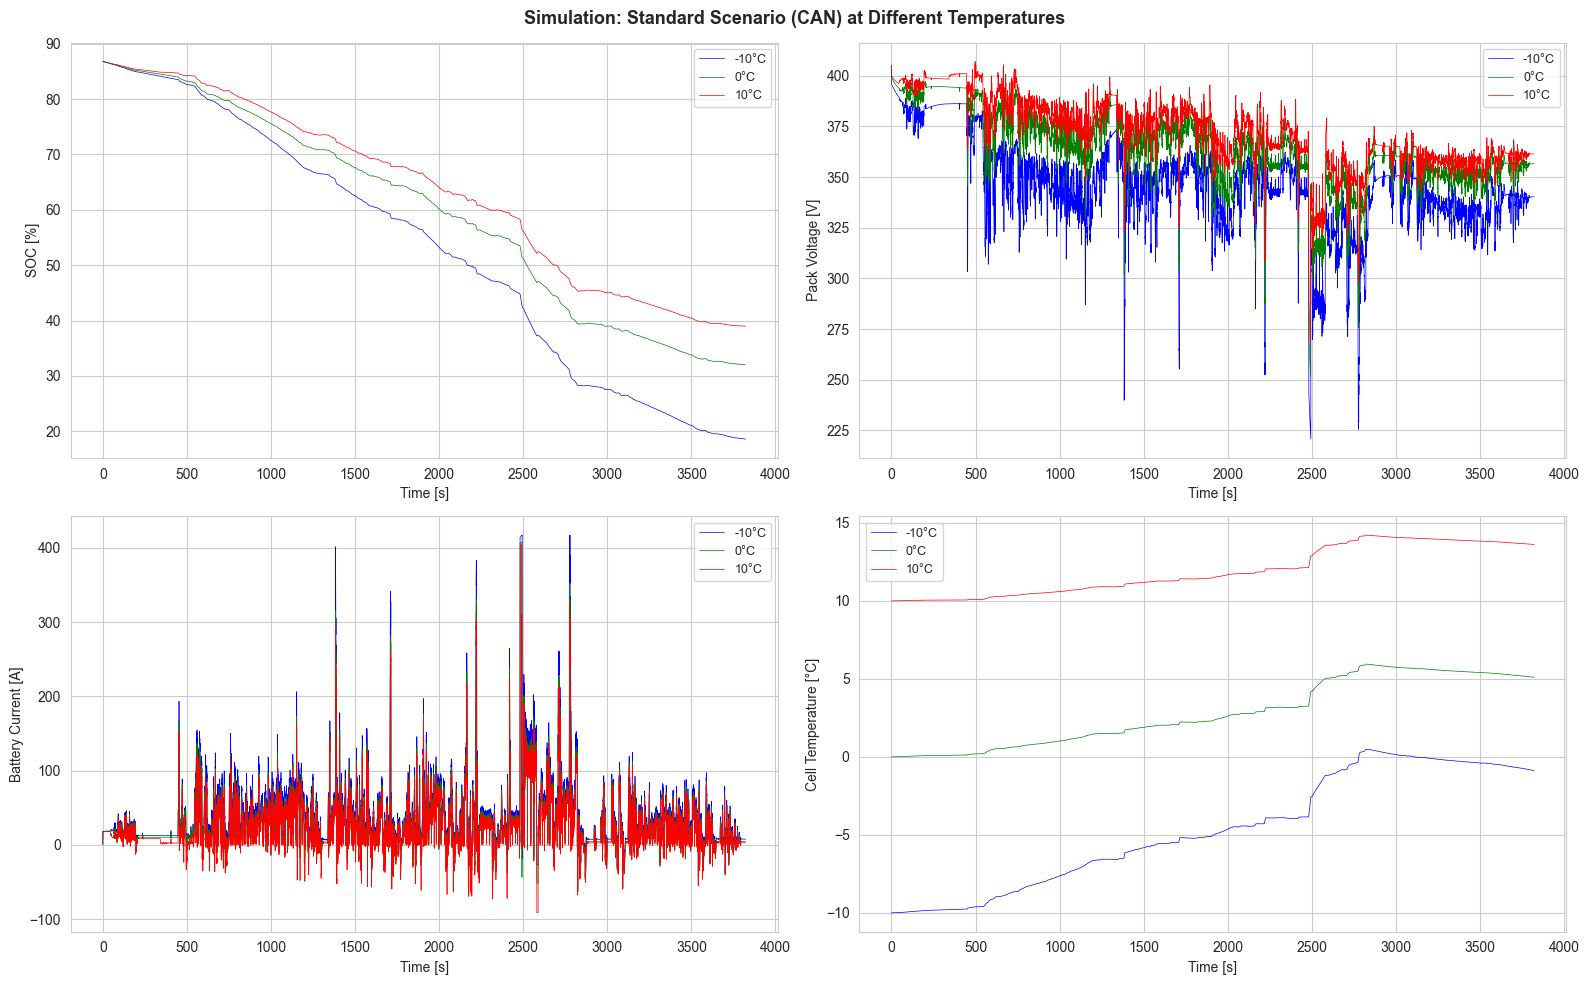

In [8]:
# compare key signals across temperatures - Standard scenario, CAN bus
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Simulation: Standard Scenario (CAN) at Different Temperatures', fontsize=13, fontweight='bold')

temps = [-10, 0, 10]
temp_colors = {-10: 'blue', 0: 'green', 10: 'red'}

plot_signals = [
    ('soc_pct', 'SOC [%]'),
    ('pack_voltage_v', 'Pack Voltage [V]'),
    ('battery_current_a', 'Battery Current [A]'),
    ('mean_cell_temperature_c', 'Cell Temperature [°C]'),
]

for ax, (col, label) in zip(axes.flat, plot_signals):
    for t in temps:
        subset = sim[(sim['scenario'] == 'Standard') & (sim['bus_type'] == 'CAN') & (sim['temperature'] == t)]
        ax.plot(subset['time_s'], subset[col], lw=0.5, color=temp_colors[t], label=f'{t}°C')
    ax.set_ylabel(label)
    ax.set_xlabel('Time [s]')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Measurement vs Simulation Comparison

Distribution comparison and time-series overlay between real and simulated data.

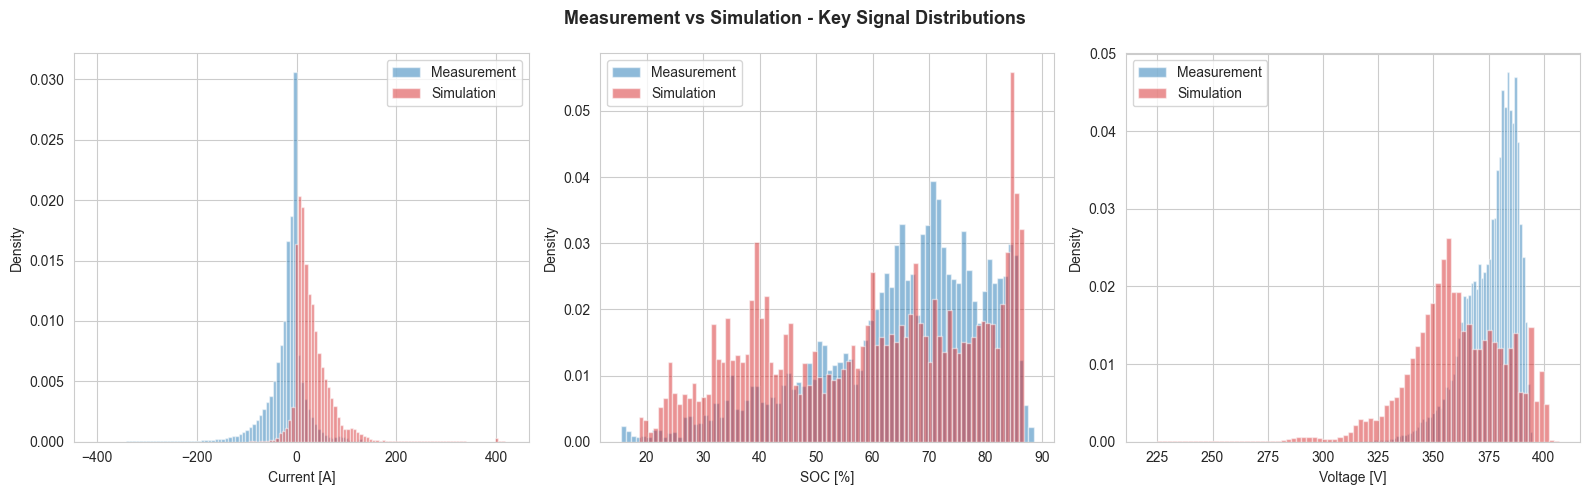

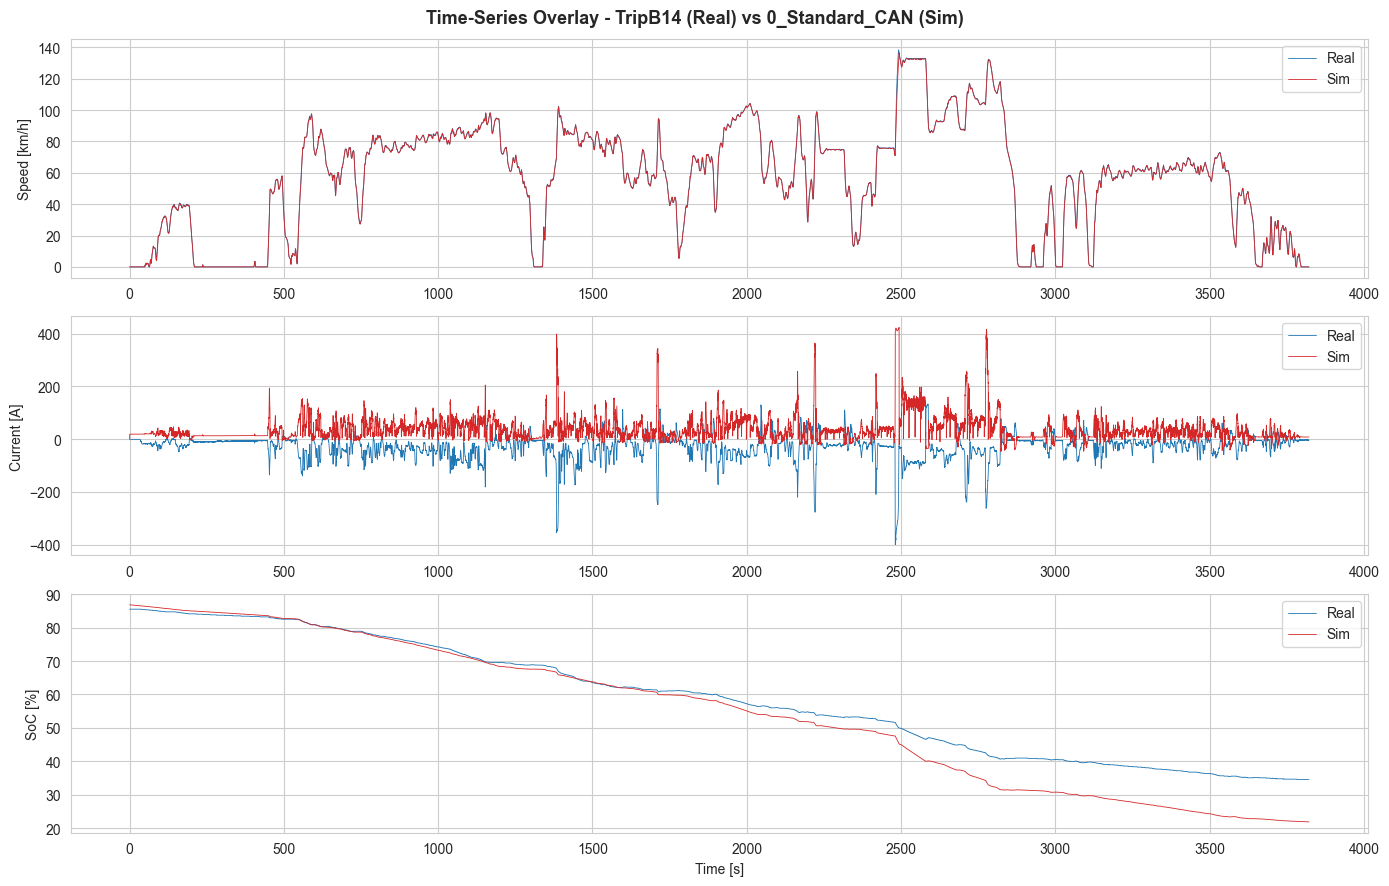

In [ ]:
# distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Measurement vs Simulation - Key Signal Distributions', fontsize=13, fontweight='bold')

compare = [
    ('battery_current_a', 'battery_current_a', 'Current [A]'),
    ('soc_pct', 'soc_pct', 'SOC [%]'),
    ('battery_voltage_v', 'pack_voltage_v', 'Voltage [V]'),
]
sim_can = sim[sim['bus_type'] == 'CAN']

for ax, (mcol, scol, label) in zip(axes, compare):
    ax.hist(meas[mcol].dropna(), bins=80, alpha=0.5, density=True, label='Measurement', color='tab:blue')
    ax.hist(sim_can[scol].dropna(), bins=80, alpha=0.5, density=True, label='Simulation', color='tab:red')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

# time-series overlay: real trip vs simulation
trip_m = meas[meas['trip_id'] == 'TripB14']
sim_std = sim[sim['sim_id'] == '0_Standard_CAN'].copy()
sim_std['speed_kmh'] = sim_std['speed_ms'] * 3.6

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Time-Series Overlay - TripB14 (Real) vs 0_Standard_CAN (Sim)', fontsize=13, fontweight='bold')

axes[0].plot(trip_m['time_s'], trip_m['velocity_kmh'], lw=0.6, label='Real', color='tab:blue')
axes[0].plot(sim_std['time_s'], sim_std['speed_kmh'], lw=0.6, label='Sim', color='tab:red')
axes[0].set_ylabel('Speed [km/h]')
axes[0].legend()

axes[1].plot(trip_m['time_s'], trip_m['battery_current_a'], lw=0.6, label='Real', color='tab:blue')
axes[1].plot(sim_std['time_s'], sim_std['battery_current_a'], lw=0.6, label='Sim', color='tab:red')
axes[1].set_ylabel('Current [A]')
axes[1].legend()

axes[2].plot(trip_m['time_s'], trip_m['soc_pct'], lw=0.6, label='Real', color='tab:blue')
axes[2].plot(sim_std['time_s'], sim_std['soc_pct'], lw=0.6, label='Sim', color='tab:red')
axes[2].set_ylabel('SoC [%]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Thermal Analysis

Battery temperature vs ambient temperature, and heating power usage across trips.

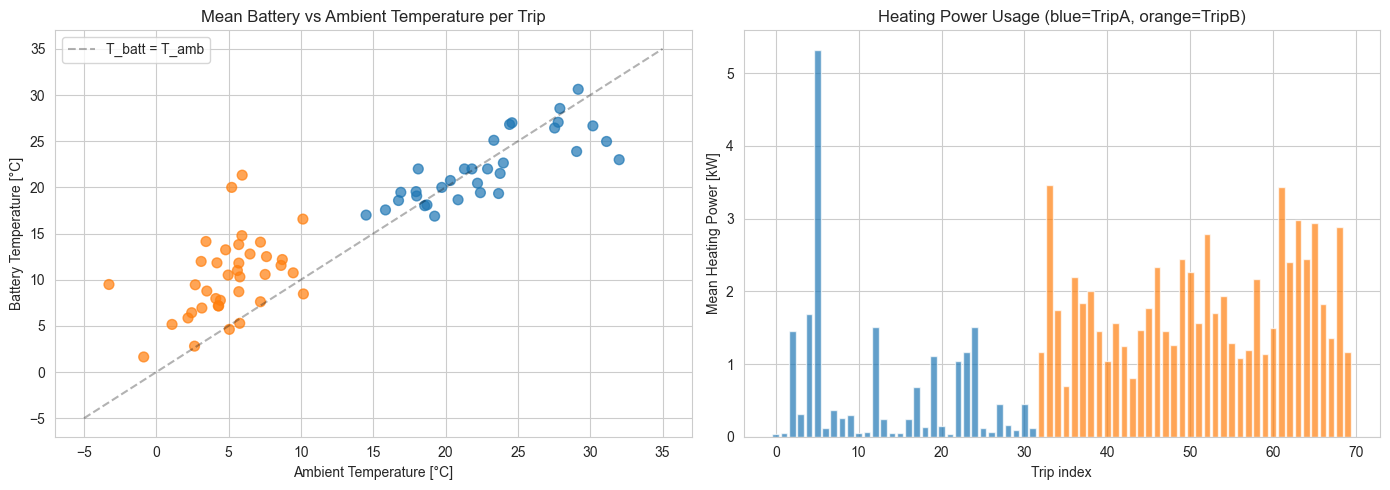

In [10]:
# battery temp vs ambient temp per trip
trip_temps = meas.groupby('trip_id').agg({
    'battery_temperature_c': 'mean',
    'ambient_temperature_c': 'mean',
    'heating_power_can_kw': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tab:blue' if t.startswith('TripA') else 'tab:orange' for t in trip_temps['trip_id']]
axes[0].scatter(trip_temps['ambient_temperature_c'], trip_temps['battery_temperature_c'],
                c=colors, s=50, alpha=0.7)
axes[0].plot([-5, 35], [-5, 35], 'k--', alpha=0.3, label='T_batt = T_amb')
axes[0].set_xlabel('Ambient Temperature [°C]')
axes[0].set_ylabel('Battery Temperature [°C]')
axes[0].set_title('Mean Battery vs Ambient Temperature per Trip')
axes[0].legend()

axes[1].bar(range(len(trip_temps)), trip_temps['heating_power_can_kw'], color=colors, alpha=0.7)
axes[1].set_xlabel('Trip index')
axes[1].set_ylabel('Mean Heating Power [kW]')
axes[1].set_title('Heating Power Usage (blue=TripA, orange=TripB)')

plt.tight_layout()
plt.show()

## 10. Simulation: Scenario Comparison

Compare SoC depletion and heating behavior across scenarios at 0°C (CAN bus).

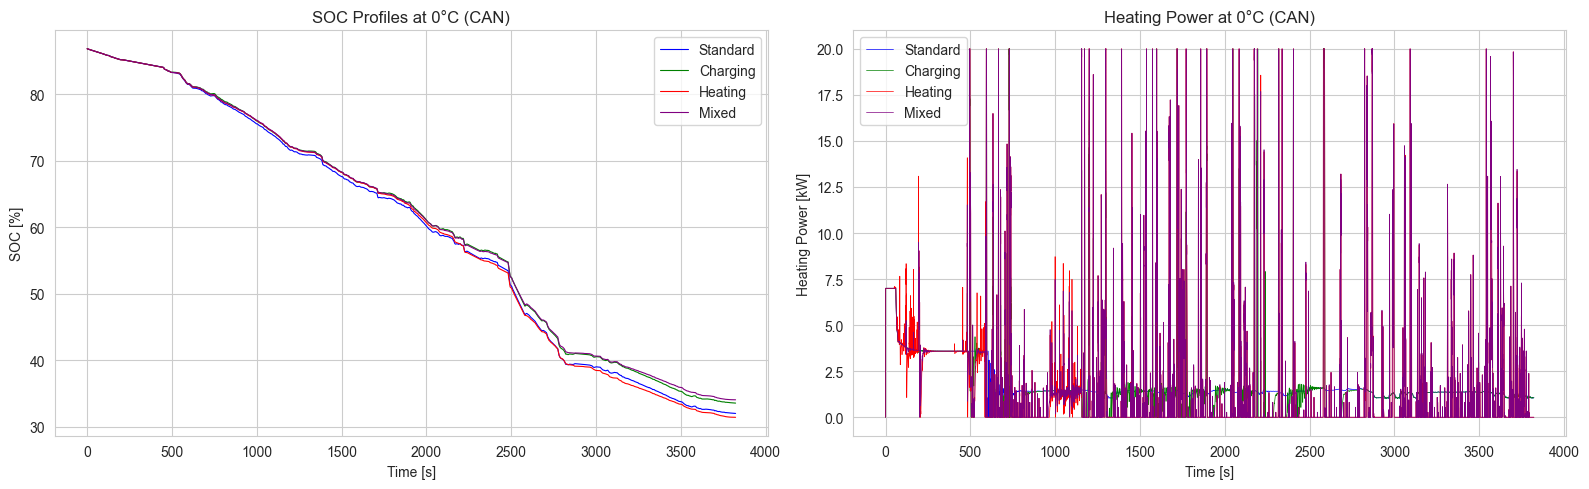

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scenarios = ['Standard', 'Charging', 'Heating', 'Mixed']
scenario_colors = {'Standard': 'blue', 'Charging': 'green', 'Heating': 'red', 'Mixed': 'purple'}

for sc in scenarios:
    subset = sim[(sim['scenario'] == sc) & (sim['bus_type'] == 'CAN') & (sim['temperature'] == 0)]
    axes[0].plot(subset['time_s'], subset['soc_pct'], lw=0.8, color=scenario_colors[sc], label=sc)
    axes[1].plot(subset['time_s'], subset['heating_power_kw'], lw=0.5, color=scenario_colors[sc], label=sc)

axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('SOC [%]')
axes[0].set_title('SOC Profiles at 0°C (CAN)')
axes[0].legend()

axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Heating Power [kW]')
axes[1].set_title('Heating Power at 0°C (CAN)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Summary Statistics

In [12]:
print('MEASUREMENT DATA SUMMARY\n')
n_A = meas['trip_id'].str.startswith('TripA').sum()
n_B = meas['trip_id'].str.startswith('TripB').sum()
print(f"Total rows: {len(meas):,}")
print(f"Trips: {meas['trip_id'].nunique()} (TripA: {n_A:,}, TripB: {n_B:,})")
print(f"Voltage: {meas['battery_voltage_v'].min():.1f} - {meas['battery_voltage_v'].max():.1f} V")
print(f"Current: {meas['battery_current_a'].min():.1f} - {meas['battery_current_a'].max():.1f} A")
print(f"SoC: {meas['soc_pct'].min():.1f} - {meas['soc_pct'].max():.1f} %")
print(f"Battery Temp: {meas['battery_temperature_c'].min():.1f} - {meas['battery_temperature_c'].max():.1f} °C")
print(f"Ambient Temp: {meas['ambient_temperature_c'].min():.1f} - {meas['ambient_temperature_c'].max():.1f} °C")

print('\nSIMULATION DATA SUMMARY\n')
print(f"Total rows: {len(sim):,}")
print(f"Simulations: {sim['sim_id'].nunique()}")
print(f"Scenarios: {sim['scenario'].unique().tolist()}")
print(f"Temperatures: {sorted(sim['temperature'].unique().tolist())} °C")
print(f"Voltage: {sim['pack_voltage_v'].min():.1f} - {sim['pack_voltage_v'].max():.1f} V")
print(f"Current: {sim['battery_current_a'].min():.1f} - {sim['battery_current_a'].max():.1f} A")
print(f"SOC: {sim['soc_pct'].min():.1f} - {sim['soc_pct'].max():.1f} %")
print(f"Cell Temp: {sim['mean_cell_temperature_c'].min():.1f} - {sim['mean_cell_temperature_c'].max():.1f} °C")

MEASUREMENT DATA SUMMARY

Total rows: 1,064,082
Trips: 70 (TripA: 467,701, TripB: 596,381)
Voltage: 301.8 - 394.8 V
Current: -404.4 - 144.5 A
SoC: 15.4 - 88.5 %
Battery Temp: -1.0 - 32.0 °C
Ambient Temp: -3.5 - 33.5 °C

SIMULATION DATA SUMMARY

Total rows: 917,280
Simulations: 24
Scenarios: ['Charging', 'Heating', 'Mixed', 'Standard']
Temperatures: [-10, 0, 10] °C
Voltage: 219.2 - 407.1 V
Current: -94.3 - 433.4 A
SOC: 18.5 - 86.8 %
Cell Temp: -10.0 - 14.2 °C
